# 1. Context

This project focuses on the development of a data engineering pipeline for
NYC taxi trip data. The main objective is to explore the available datasets,
identify relevant data quality issues and temporal patterns, and use these
findings to define the requirements of a reliable and reproducible data
pipeline.

The exploratory analysis focuses primarily on taxi trip records, while the
geographical dataset is used to provide context for pickup and drop-off
locations.

The findings from this analysis will guide future decisions regarding
data validation, transformation, storage, and pipeline processing.

# 2. Data Sources

In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import polars as pl
pio.renderers.default = "vscode"
import os

raw_path = "../data/raw"

os.listdir(raw_path)

['original_cleaned_nyc_taxi_data_2018.csv',
 'taxi_zone_geo.csv',
 '.complete',
 'taxi_trip_data.csv']

In [2]:
trips_lazy = pl.scan_csv("../data/raw/taxi_trip_data.csv")
trips_full = trips_lazy.collect(engine='streaming')
trips = trips_full.sample(n=100_000, seed=42).to_pandas()

# Loading the geographics zones .csv
zones = pd.read_csv("../data/raw/taxi_zone_geo.csv")

# Loading "clean" data
cleaned = pd.read_csv("../data/raw/original_cleaned_nyc_taxi_data_2018.csv", nrows=100_000)

Polars was used to load the full dataset because of local RAM limitations — it handles the heavy lifting (loading the raw CSV) while pandas is used for the rest of the analysis.

# 3. Overview of the 3 datasets

## Quick Inspection

In [3]:
def quick(df):
    print("shape:", df.shape)
    print("\ncolumns:")
    print(df.columns)
    print("\ndtypes:")
    print(df.dtypes)
    print("\nisnull:")
    print(df.isnull().sum())
    display(df.head())

## Trips

In [4]:
quick(trips)

shape: (100000, 17)

columns:
Index(['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_distance', 'rate_code', 'store_and_fwd_flag', 'payment_type',
       'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'imp_surcharge', 'total_amount', 'pickup_location_id',
       'dropoff_location_id'],
      dtype='object')

dtypes:
vendor_id                int64
pickup_datetime         object
dropoff_datetime        object
passenger_count          int64
trip_distance          float64
rate_code                int64
store_and_fwd_flag      object
payment_type             int64
fare_amount            float64
extra                  float64
mta_tax                float64
tip_amount             float64
tolls_amount           float64
imp_surcharge          float64
total_amount           float64
pickup_location_id       int64
dropoff_location_id      int64
dtype: object

isnull:
vendor_id              0
pickup_datetime        0
dropoff_datetime     

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
0,1,2018-06-29 07:56:24,2018-06-29 08:34:14,1,4.20,1,N,1,25.0,0.0,0.5,6.45,0.00,0.3,32.25,24,161
1,2,2018-05-28 03:42:15,2018-05-28 03:59:44,1,9.24,1,N,2,26.5,0.5,0.5,0.00,0.00,0.3,27.80,68,244
2,2,2018-02-25 00:39:12,2018-02-25 01:00:55,2,9.16,1,N,1,27.5,0.5,0.5,6.91,5.76,0.3,41.47,244,129
3,1,2018-04-15 16:49:09,2018-04-15 17:50:15,1,18.70,2,N,1,52.0,0.0,0.5,5.28,0.00,0.3,58.08,132,234
4,2,2018-11-20 21:45:41,2018-11-20 22:17:13,1,7.49,1,N,1,28.0,0.5,0.5,5.86,0.00,0.3,35.16,233,189


## Zones

In [5]:
quick(zones)

shape: (263, 4)

columns:
Index(['zone_id', 'zone_name', 'borough', 'zone_geom'], dtype='object')

dtypes:
zone_id       int64
zone_name    object
borough      object
zone_geom    object
dtype: object

isnull:
zone_id      0
zone_name    0
borough      0
zone_geom    0
dtype: int64


,zone_id,zone_name,borough,zone_geom
0,1,Newark Airport,EWR,"POLYGON((-74.1856319999999 40.6916479999999, -..."
1,3,Allerton/Pelham Gardens,Bronx,"POLYGON((-73.848596761 40.8716707849999, -73.8..."
2,18,Bedford Park,Bronx,"POLYGON((-73.8844286139999 40.8668003789999, -..."
3,20,Belmont,Bronx,"POLYGON((-73.8839239579998 40.8644177609999, -..."
4,31,Bronx Park,Bronx,"POLYGON((-73.8710017319999 40.8572767429999, -..."


## Cleaned

In [6]:
quick(cleaned)

shape: (100000, 21)

columns:
Index(['Unnamed: 0', 'trip_distance', 'rate_code', 'store_and_fwd_flag',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'imp_surcharge', 'total_amount', 'pickup_location_id',
       'dropoff_location_id', 'year', 'month', 'day', 'day_of_week',
       'hour_of_day', 'trip_duration', 'calculated_total_amount'],
      dtype='object')

dtypes:
Unnamed: 0                   int64
trip_distance              float64
rate_code                    int64
store_and_fwd_flag          object
payment_type                 int64
fare_amount                float64
extra                      float64
mta_tax                    float64
tip_amount                 float64
tolls_amount               float64
imp_surcharge              float64
total_amount               float64
pickup_location_id           int64
dropoff_location_id          int64
year                         int64
month                        int64
day                 

,Unnamed: 0,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,...,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,calculated_total_amount
0,3,16.97,1,N,1,49.5,0.0,0.5,5.61,5.76,...,61.67,231,138,2018,3,29,3,13,3317.0,61.67
1,4,14.45,1,N,1,45.5,0.0,0.5,10.41,5.76,...,62.47,87,138,2018,3,29,3,14,3648.0,62.47
2,5,11.60,1,N,1,42.0,0.0,0.5,14.57,5.76,...,63.13,68,138,2018,3,29,3,14,3540.0,63.13
3,10,5.10,1,N,1,26.5,1.0,0.5,5.65,0.00,...,33.95,186,33,2018,3,29,3,16,2585.0,33.95
4,12,11.11,1,N,1,45.5,1.0,0.5,10.61,5.76,...,63.67,163,138,2018,3,29,3,16,4521.0,63.67


## General view

In [7]:
datasets = {
    "trips": trips,
    "zones": zones,
    "cleaned": cleaned
}

for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nTypes:")
    print(df.dtypes)


===== trips =====
Shape: (100000, 17)
Columns: ['vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'rate_code', 'store_and_fwd_flag', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'imp_surcharge', 'total_amount', 'pickup_location_id', 'dropoff_location_id']

Types:
vendor_id                int64
pickup_datetime         object
dropoff_datetime        object
passenger_count          int64
trip_distance          float64
rate_code                int64
store_and_fwd_flag      object
payment_type             int64
fare_amount            float64
extra                  float64
mta_tax                float64
tip_amount             float64
tolls_amount           float64
imp_surcharge          float64
total_amount           float64
pickup_location_id       int64
dropoff_location_id      int64
dtype: object

===== zones =====
Shape: (263, 4)
Columns: ['zone_id', 'zone_name', 'borough', 'zone_geom']

Types:
zone_id       int64

The `taxi_trip_data` dataset was selected as the primary source for this
analysis because it contains the taxi trip records that will be used
throughout the project.

The `taxi_zone_geo` dataset provides geographical information associated
with taxi zones and will be used to validate trip location data.

The `original_cleaned_nyc_taxi_data_2018` dataset will be evaluated as an
additional reference dataset to understand its relationship with the primary
trip data.

# 4. Relationship between datasets

This section compares the three datasets loaded in section 2 to understand how they relate to each other, before deciding how (or if) `taxi_zone_geo` and `original_cleaned_nyc_taxi_data_2018` are used alongside the primary `taxi_trip_data` source.

### 4.1 `taxi_trip_data` vs `taxi_zone_geo`

Both `pickup_location_id` and `dropoff_location_id` in `taxi_trip_data` are expected to reference `zone_id` in `taxi_zone_geo`. Whether every trip's location ID actually has a matching zone is checked in detail in section 7 (`7.3 Unmatched records`) — this section only confirms the two datasets are meant to be joined on this key.

In [8]:
zones["zone_id"].dtype, trips["pickup_location_id"].dtype, trips["dropoff_location_id"].dtype

(dtype('int64'), dtype('int64'), dtype('int64'))

> **Pending —** confirm the three dtypes above match, which is needed for a clean join in the pipeline.

### 4.2 `taxi_trip_data` vs `original_cleaned_nyc_taxi_data_2018`

`cleaned` shares most monetary and trip columns with `trips` (`trip_distance`, `fare_amount`, `tip_amount`, `total_amount`, `pickup_location_id`, `dropoff_location_id`, etc.), but differs in two ways: it does not include `vendor_id` or the raw `pickup_datetime`/`dropoff_datetime` timestamps, and it adds several derived columns instead (`year`, `month`, `day`, `day_of_week`, `hour_of_day`, `trip_duration`, `calculated_total_amount`). This points to `cleaned` being a pre-processed, feature-engineered version of similar trip data, not a raw extract — likely already cleaned of some of the issues found in 5.2/5.3.

In [9]:
(cleaned["trip_distance"] <= 0).sum()

np.int64(0)

In [10]:
(cleaned["trip_duration"] < 0).sum()

np.int64(0)

> **Pending —** run the two cells above. If both are (close to) 0, it confirms `cleaned` has already had the equivalent of the 5.2/5.3 business-rule fixes applied — useful as a validation reference, but it does not replace the pipeline's own cleaning logic, since the pipeline works from the raw `taxi_trip_data` (as decided in section 3).

### 4.3 Conclusion

`taxi_zone_geo` will be used as a lookup/dimension table (`dim_zone` in the eventual warehouse) to validate and enrich location IDs. `original_cleaned_nyc_taxi_data_2018` will be kept only as a reference for sanity-checking the pipeline's own cleaning logic once built — it is not used as an input to the pipeline itself, since the project's source of truth is the raw `taxi_trip_data` (as decided in section 3).

# 5. EDA - taxi_trip_data.csv

## 5.1 Structure and types

In [11]:
# import pandas as pd

# #Loading the taxi trips .csv
# trips = pd.read_csv("../data/raw/taxi_trip_data.csv", nrows=100_000)

In [12]:
trips.shape

(100000, 17)

In [13]:
trips.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
0,1,2018-06-29 07:56:24,2018-06-29 08:34:14,1,4.20,1,N,1,25.0,0.0,0.5,6.45,0.00,0.3,32.25,24,161
1,2,2018-05-28 03:42:15,2018-05-28 03:59:44,1,9.24,1,N,2,26.5,0.5,0.5,0.00,0.00,0.3,27.80,68,244
2,2,2018-02-25 00:39:12,2018-02-25 01:00:55,2,9.16,1,N,1,27.5,0.5,0.5,6.91,5.76,0.3,41.47,244,129
3,1,2018-04-15 16:49:09,2018-04-15 17:50:15,1,18.70,2,N,1,52.0,0.0,0.5,5.28,0.00,0.3,58.08,132,234
4,2,2018-11-20 21:45:41,2018-11-20 22:17:13,1,7.49,1,N,1,28.0,0.5,0.5,5.86,0.00,0.3,35.16,233,189


In [14]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   vendor_id            100000 non-null  int64  
 1   pickup_datetime      100000 non-null  object 
 2   dropoff_datetime     100000 non-null  object 
 3   passenger_count      100000 non-null  int64  
 4   trip_distance        100000 non-null  float64
 5   rate_code            100000 non-null  int64  
 6   store_and_fwd_flag   100000 non-null  object 
 7   payment_type         100000 non-null  int64  
 8   fare_amount          100000 non-null  float64
 9   extra                100000 non-null  float64
 10  mta_tax              100000 non-null  float64
 11  tip_amount           100000 non-null  float64
 12  tolls_amount         100000 non-null  float64
 13  imp_surcharge        100000 non-null  float64
 14  total_amount         100000 non-null  float64
 15  pickup_location_id

`pickup_datetime` and `dropoff_datetime` were loaded as `object` values.
Although the values represent timestamps, they are not currently stored as
datetime objects and should be converted to an appropriate
datetime type during the transformation stage of the pipeline.

`payment_type` is stored as an integer but represents a categorical variable.
The dataset documentation provides the meaning of each code. These codes
will need to be mapped to their corresponding payment categories during
the transformation stage.

`rate_code` is stored as an integer but represents a categorical variable,
as its values correspond to predefined rate categories rather than
continuous numerical measurements.

`store_and_fwd_flag` is stored as an `object` type but represents a
categorical variable.

In [15]:
schema = pd.DataFrame({
    "column": trips.columns,
    "dtype": trips.dtypes.values,
    "null_count": trips.isnull().sum().values,
    "unique_count": trips.nunique().values
})

schema

,column,dtype,null_count,unique_count
0,vendor_id,int64,0,3
1,pickup_datetime,object,0,99749
2,dropoff_datetime,object,0,99716
3,passenger_count,int64,0,8
4,trip_distance,float64,0,2925
5,rate_code,int64,0,7
6,store_and_fwd_flag,object,0,2
7,payment_type,int64,0,4
8,fare_amount,float64,0,805
9,extra,float64,0,13


The sample contains 100,000 records across 17 columns.

The initial schema inspection identified:
- 8 `float64` columns
- 6 `int64` columns
- 3 `object` columns

No null values were identified in the analyzed sample.

## 5.2 Data quality

In [16]:
trips.isnull().sum()

vendor_id              0
pickup_datetime        0
dropoff_datetime       0
passenger_count        0
trip_distance          0
rate_code              0
store_and_fwd_flag     0
payment_type           0
fare_amount            0
extra                  0
mta_tax                0
tip_amount             0
tolls_amount           0
imp_surcharge          0
total_amount           0
pickup_location_id     0
dropoff_location_id    0
dtype: int64

In [17]:
trips.duplicated().sum()

np.int64(53)

In [18]:
trips['payment_type'].value_counts()

payment_type
1    82701
2    16067
3      979
4      253
Name: count, dtype: int64

In [19]:
trips["vendor_id"].value_counts()

vendor_id
2    60028
1    39465
4      507
Name: count, dtype: int64

`vendor_id` shows an unexpected value: 4 (507 rows). Documented NYC TLC vendor codes for this dataset are only 1 and 2 — this will be investigated further below.

In [20]:
trips[trips["vendor_id"] == 4].shape

(507, 17)

In [21]:
trips["rate_code"].value_counts()

rate_code
1     90850
2      4693
5      2460
3      1556
4       425
99       13
6         3
Name: count, dtype: int64

`rate_code` shows an unexpected value: 99 (13 rows), which falls outside the documented TLC rate code range (1-6).

In [22]:
trips[trips["rate_code"] == 99].shape

(13, 17)

Both anomalies are small in volume (507 and 13 rows respectively). Rather than removing them, they will be treated as an 'unknown/unmapped' category in the pipeline because removing them would discard otherwise valid trip data just because the code doesn't match the documented set.

In [23]:
trips[trips["trip_distance"] <= 0].count()

vendor_id              2765
pickup_datetime        2765
dropoff_datetime       2765
passenger_count        2765
trip_distance          2765
rate_code              2765
store_and_fwd_flag     2765
payment_type           2765
fare_amount            2765
extra                  2765
mta_tax                2765
tip_amount             2765
tolls_amount           2765
imp_surcharge          2765
total_amount           2765
pickup_location_id     2765
dropoff_location_id    2765
dtype: int64

In [24]:
trips[trips ['pickup_location_id'] == trips['dropoff_location_id']].count()

vendor_id              6165
pickup_datetime        6165
dropoff_datetime       6165
passenger_count        6165
trip_distance          6165
rate_code              6165
store_and_fwd_flag     6165
payment_type           6165
fare_amount            6165
extra                  6165
mta_tax                6165
tip_amount             6165
tolls_amount           6165
imp_surcharge          6165
total_amount           6165
pickup_location_id     6165
dropoff_location_id    6165
dtype: int64

The following cells investigate these rows in more detail.

In [25]:
trips_wrongs = trips[trips["trip_distance"] <= 0]
trips_wrongs.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
57,1,2018-12-11 14:19:05,2018-12-11 14:19:20,1,0.0,5,N,1,60.00,0.0,0.0,15.05,0.00,0.3,75.35,13,13
104,2,2018-12-14 14:48:23,2018-12-14 14:48:28,2,0.0,1,N,2,2.50,0.0,0.5,0.00,0.00,0.3,3.30,161,161
143,1,2018-05-19 14:58:16,2018-05-19 15:00:17,1,0.0,1,N,1,3.00,0.0,0.5,0.57,0.00,0.3,4.37,234,234
151,4,2018-12-27 05:45:50,2018-12-27 05:46:01,1,0.0,5,N,2,218.75,0.0,0.0,0.00,5.76,0.3,224.81,132,265
154,2,2018-03-06 19:00:57,2018-03-06 19:01:02,2,0.0,5,N,1,16.80,0.0,0.0,0.35,0.00,0.3,17.45,68,68


In [26]:
trips_wrongs.shape

(2765, 17)

In [96]:
duplicates = trips[trips.duplicated(keep=False)]

In [28]:
duplicates.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
546,2,2018-03-19 07:25:54,2018-03-19 08:05:59,6,8.97,1,N,1,30.5,0.0,0.5,7.41,5.76,0.3,44.47,138,234
569,1,2018-03-23 19:53:21,2018-03-23 20:22:08,1,10.60,1,N,1,33.5,1.0,0.5,9.35,11.52,0.3,56.17,138,163
715,1,2018-03-01 13:59:12,2018-03-01 14:19:38,2,9.30,1,N,1,27.0,0.0,0.5,10.05,5.76,0.3,43.61,264,264
768,1,2018-03-18 10:59:21,2018-03-18 11:22:03,1,10.10,1,N,1,31.0,0.0,0.5,6.00,2.64,0.3,40.44,142,220
1267,1,2018-03-25 07:34:13,2018-03-25 07:50:27,2,9.80,1,N,1,28.0,0.0,0.5,6.90,5.76,0.3,41.46,164,138


In [29]:
duplicates.shape

(106, 17)

In [30]:
duplicates.sort_values(
    by=["pickup_datetime", "dropoff_datetime"]
).head(10)

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
715,1,2018-03-01 13:59:12,2018-03-01 14:19:38,2,9.30,1,N,1,27.0,0.0,0.5,10.05,5.76,0.3,43.61,264,264
68926,1,2018-03-01 13:59:12,2018-03-01 14:19:38,2,9.30,1,N,1,27.0,0.0,0.5,10.05,5.76,0.3,43.61,264,264
12093,2,2018-03-01 21:01:50,2018-03-01 21:43:23,1,13.76,1,N,1,41.0,0.5,0.5,8.46,0.00,0.3,50.76,233,165
90235,2,2018-03-01 21:01:50,2018-03-01 21:43:23,1,13.76,1,N,1,41.0,0.5,0.5,8.46,0.00,0.3,50.76,233,165
52309,2,2018-03-02 02:56:03,2018-03-02 03:22:29,1,5.72,1,N,1,22.0,0.5,0.5,6.99,0.00,0.3,30.29,230,145
88662,2,2018-03-02 02:56:03,2018-03-02 03:22:29,1,5.72,1,N,1,22.0,0.5,0.5,6.99,0.00,0.3,30.29,230,145
8906,1,2018-03-02 16:36:14,2018-03-02 17:13:18,4,14.80,1,N,2,42.5,1.0,0.5,0.00,0.00,0.3,44.30,264,264
59195,1,2018-03-02 16:36:14,2018-03-02 17:13:18,4,14.80,1,N,2,42.5,1.0,0.5,0.00,0.00,0.3,44.30,264,264
30790,1,2018-03-06 01:05:16,2018-03-06 01:23:55,1,7.60,1,Y,1,24.0,0.5,0.5,5.05,0.00,0.3,30.35,163,243
52486,1,2018-03-06 01:05:16,2018-03-06 01:23:55,1,7.60,1,Y,1,24.0,0.5,0.5,5.05,0.00,0.3,30.35,163,243


53 duplicated rows were found. Every column matches across the duplicated pairs, which suggests genuine duplicates rather than coincidental matches, the next check confirms this more rigorously by comparing all columns explicitly.

This confirms the duplicates are genuine: every column matches across the duplicated rows, not just the ones used in the first check.

Within the 100,000-row sample, 53 duplicated pairs were found, corresponding to 106 affected rows.

These duplicate rows will be removed during the pipeline's transformation stage.

In [31]:
duplicate_rows = len(duplicates)
percentage = duplicate_rows / len(trips) * 100

print(f"Rows involved in duplication: {duplicate_rows}")
print(f"Percentage: {percentage:.3f}%")

Rows involved in duplication: 106
Percentage: 0.106%


In [32]:
duplicate_counts = trips.value_counts()

duplicate_counts[duplicate_counts > 1].head(20)

vendor_id  pickup_datetime      dropoff_datetime     passenger_count  trip_distance  rate_code  store_and_fwd_flag  payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  imp_surcharge  total_amount  pickup_location_id  dropoff_location_id
2          2018-03-28 13:51:04  2018-03-28 14:25:29  1                9.55           1          N                   1             32.5         0.0    0.5      7.81        5.76          0.3            46.87         138                 79                     2
           2018-03-11 15:52:55  2018-03-11 16:31:50  1                14.90          1          N                   1             43.0         0.0    0.5      12.39       5.76          0.3            61.95         138                 13                     2
1          2018-03-23 16:56:09  2018-03-23 17:38:24  1                7.30           1          N                   1             31.5         1.0    0.5      6.65        0.00          0.3            39.95         141           

In [33]:
trips_wrongs_rows = len(trips_wrongs)
percentage = trips_wrongs_rows / len(trips) * 100

print(f"Rows involved in trip_distance <= 0: {trips_wrongs_rows}")
print(f"Percentage: {percentage:.3f}%")

Rows involved in trip_distance <= 0: 2765
Percentage: 2.765%


2,765 rows out of 100,000 (2.77%) have `trip_distance <= 0`, a small share of the sample.

In [34]:
trips_location_wrong = trips[trips['pickup_location_id'] == trips["dropoff_location_id"]]

trips_location_wrong.shape

(6165, 17)

In [35]:
trips_location_wrong[trips_location_wrong['trip_distance'] <= 0].shape

(2071, 17)

In [36]:
trips_location_wrong[trips_location_wrong['trip_distance'] < 0].shape

(0, 17)

In [37]:
trips_location_wrong.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id
25,1,2018-08-16 22:03:54,2018-08-16 22:28:48,2,8.30,1,N,1,26.0,0.5,0.5,5.45,0.0,0.3,32.75,264,264
57,1,2018-12-11 14:19:05,2018-12-11 14:19:20,1,0.00,5,N,1,60.0,0.0,0.0,15.05,0.0,0.3,75.35,13,13
74,2,2018-08-08 11:11:44,2018-08-08 11:12:38,1,0.15,1,N,2,3.0,0.0,0.5,0.00,0.0,0.3,3.80,132,132
85,2,2018-03-23 18:55:17,2018-03-23 19:07:03,1,4.21,5,N,1,84.0,0.0,0.5,16.96,0.0,0.3,101.76,265,265
86,1,2018-05-16 21:21:43,2018-05-16 21:55:09,2,5.90,1,N,1,23.5,0.5,0.5,4.96,0.0,0.3,29.76,264,264


In [38]:
trips_no_distance = trips_location_wrong[trips_location_wrong['trip_distance'] == 0]
trips_no_distance.shape

(2071, 17)

In [39]:
trips_no_distance[trips_no_distance["fare_amount"] == 0].shape

(35, 17)

In [40]:
trips_no_distance[trips_no_distance["fare_amount"] < 0].shape

(43, 17)

In [41]:
fare_invalid = trips_no_distance[
    trips_no_distance["fare_amount"] <= 0
]

fare_invalid[[
    "pickup_datetime",
    "dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "payment_type",
    "rate_code"
]]

,pickup_datetime,dropoff_datetime,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,payment_type,rate_code
1448,2018-02-08 21:12:12,2018-02-08 21:12:12,0.0,0.0,0.0,0.0,0.00,0.00,0.30,2,5
7471,2018-03-25 11:07:07,2018-03-25 11:08:00,0.0,-2.5,0.0,-0.5,-0.66,0.00,-3.96,3,1
8064,2018-05-17 18:03:58,2018-05-17 18:04:41,0.0,0.0,0.0,0.0,0.00,0.00,0.00,2,2
12540,2018-03-05 12:24:10,2018-03-05 12:24:18,0.0,-2.5,0.0,-0.5,0.00,0.00,-3.30,3,1
13552,2018-02-17 12:41:29,2018-02-17 12:41:42,0.0,-2.5,0.0,-0.5,0.00,0.00,-3.30,3,1
...,...,...,...,...,...,...,...,...,...,...,...
95165,2018-05-27 19:46:59,2018-05-27 19:47:20,0.0,-52.0,0.0,-0.5,0.00,-5.76,-58.56,4,2
98988,2018-12-22 13:15:07,2018-12-22 13:15:59,0.0,-2.5,0.0,-0.5,0.00,0.00,-3.30,4,1
99540,2018-12-11 16:28:40,2018-12-11 16:30:01,0.0,-3.0,-1.0,-0.5,0.00,0.00,-4.80,4,1
99581,2018-07-07 23:32:31,2018-07-07 23:32:40,0.0,-2.5,-0.5,-0.5,0.00,0.00,-3.80,4,1


35 rows have `fare_amount == 0` and 39 rows have `fare_amount < 0`. A closer look also shows negative and zero values in `total_amount`, checked next.

2,071 of the rows where `pickup_location_id == dropoff_location_id` also have `trip_distance == 0`.

`pickup_location_id == dropoff_location_id` is not an error by itself, a trip can start and end in the same zone. However, within this subset, the 2,071 rows with `trip_distance == 0` are a genuine data quality issue.

In [42]:
trips[trips['total_amount'] <= 0].shape

(332, 17)

In [43]:
trips[trips['total_amount'] == 0].shape

(50, 17)

In [44]:
trips[trips['total_amount'] < 0].shape

(282, 17)

In [45]:
total_amount_invalid = trips[
    trips["total_amount"] <= 0
]

total_amount_invalid[[
    "pickup_datetime",
    "dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "payment_type",
    "rate_code"
]]

,pickup_datetime,dropoff_datetime,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,payment_type,rate_code
139,2018-10-12 19:50:09,2018-10-12 19:55:24,0.42,-5.0,-1.0,-0.5,0.0,0.0,-6.8,4,1
178,2018-05-21 16:40:49,2018-05-21 16:41:53,0.11,0.0,0.0,0.0,0.0,0.0,0.0,2,2
194,2018-02-03 15:19:04,2018-02-03 15:25:13,0.68,-52.0,0.0,-0.5,0.0,0.0,-52.8,3,2
523,2018-09-21 05:04:10,2018-09-21 05:32:40,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1,1
882,2018-02-05 17:08:20,2018-02-05 17:08:23,0.01,-52.0,-4.5,-0.5,0.0,0.0,-57.3,3,2
...,...,...,...,...,...,...,...,...,...,...,...
98810,2018-03-09 14:00:40,2018-03-09 14:01:09,0.03,-2.5,0.0,-0.5,0.0,0.0,-3.3,3,1
98988,2018-12-22 13:15:07,2018-12-22 13:15:59,0.00,-2.5,0.0,-0.5,0.0,0.0,-3.3,4,1
99540,2018-12-11 16:28:40,2018-12-11 16:30:01,0.00,-3.0,-1.0,-0.5,0.0,0.0,-4.8,4,1
99581,2018-07-07 23:32:31,2018-07-07 23:32:40,0.00,-2.5,-0.5,-0.5,0.0,0.0,-3.8,4,1


`total_amount` being negative correlates with the individual fare components (`fare_amount`, `extra`, etc.) also being negative, consistent with `total_amount` being a direct sum of those columns.

## 5.3 Time series analysis

In [46]:
trips_temp = trips.copy()

trips_temp["pickup_datetime"] = pd.to_datetime(
    trips_temp["pickup_datetime"]
)

trips_temp["dropoff_datetime"] = pd.to_datetime(
    trips_temp["dropoff_datetime"]
)

trips_temp[["pickup_datetime", "dropoff_datetime"]].dtypes

pickup_datetime     datetime64[ns]
dropoff_datetime    datetime64[ns]
dtype: object

In [47]:
trips_temp["pickup_datetime"].min()

Timestamp('2018-01-01 00:10:18')

In [48]:
trips_temp["pickup_datetime"].max()

Timestamp('2018-12-31 23:56:06')

In [49]:
trips_temp["dropoff_datetime"].min()

Timestamp('2018-01-01 00:42:24')

In [50]:
trips_temp["dropoff_datetime"].max()

Timestamp('2019-01-01 00:14:29')

The sample covers the period defined by the minimum and maximum values observed in `pickup_datetime` and `dropoff_datetime`.

In [51]:
trips_temp["trip_duration"] = (
    trips_temp["dropoff_datetime"]
    - trips_temp["pickup_datetime"]
)

trips_temp["trip_duration_minutes"] = (
    trips_temp["trip_duration"].dt.total_seconds() / 60
)

trips_temp["trip_duration_minutes"].describe()

count    100000.000000
mean         36.276412
std          84.342657
min         -37.300000
25%          22.700000
50%          30.150000
75%          38.750000
max        1439.366667
Name: trip_duration_minutes, dtype: float64

A negative trip duration isn't possible — this is investigated further below.

In [52]:
(trips_temp["trip_duration_minutes"] < 0).sum()

np.int64(5)

We have 5 trips that have a duration less than 0 minutes

In [53]:
(trips_temp["trip_duration_minutes"] == 0).sum()

np.int64(208)

We have 208 trips that have a duration equal 0 minutes

First, let's look at the rows with negative duration.

In [54]:
negative_duration = trips_temp[trips_temp["trip_duration_minutes"] < 0]

negative_duration[
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "fare_amount",
        "pickup_location_id",
        "dropoff_location_id"
    ]
]

,pickup_datetime,dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,pickup_location_id,dropoff_location_id
11353,2018-11-04 01:45:29,2018-11-04 01:08:11,-37.300000,11.90,33.5,13,7
68604,2018-11-04 01:45:24,2018-11-04 01:16:39,-28.750000,11.30,34.5,50,89
73627,2018-11-04 01:33:13,2018-11-04 01:03:47,-29.433333,5.30,22.5,144,229
86477,2018-11-04 01:54:07,2018-11-04 01:20:43,-33.400000,5.80,21.5,186,7
88115,2018-11-04 01:44:40,2018-11-04 01:27:26,-17.233333,8.15,32.5,79,116


### Discovered this wile talking with claude

Looking at the actual rows, all 5 negative-duration trips share something in common: every single one has a `pickup_datetime` on 2018-11-04, between 1:00 AM and 2:00 AM.

November 4, 2018 was the Daylight Saving Time transition date in the US — clocks moved back one hour at 2:00 AM, meaning the 1:00-2:00 AM window occurred twice that night. If the timestamps weren't recorded with timezone/DST awareness, a trip that started during the 'first' 1 AM and ended during the 'second' 1 AM (after the clocks rolled back) would show a `dropoff_datetime` that looks earlier than `pickup_datetime` — even though the trip happened normally.

This changes how these rows should be treated: they aren't random data entry errors, they're a systematic artifact tied to a specific calendar event. Two options for the pipeline:
1. Remove them (simplest, and what we'll do for now, since it's only 5 rows)
2. Correct the `dropoff_datetime` by adding an hour when this exact pattern is detected (more correct, more complex)

For this project we'll go with option 1, but document the real cause instead of treating it as an unexplained error.

### Trip Duration Findings

Trip duration was calculated from the difference between `dropoff_datetime` and `pickup_datetime`.

The sample contains:
- 5 trips with negative duration;
- 208 trips with zero duration.

All 5 negative-duration trips occurred on 2018-11-04 between 1:00 AM and 2:00 AM — the exact date and time window of the US Daylight Saving Time transition that year. This is treated as an explained data artifact rather than a random error: these records will still be removed during the pipeline transformation stage (only 5 rows, negligible impact), but the cause is documented rather than left unexplained.

Zero-duration trips require contextual analysis because a zero duration does not necessarily imply that the entire trip record is invalid.

In [55]:
trips_temp["pickup_hour"] = trips_temp["pickup_datetime"].dt.hour

trips_by_hour = (
    trips_temp["pickup_hour"]
    .value_counts()
    .sort_index()
)

trips_by_hour

pickup_hour
0     3506
1     2195
2     1395
3     1123
4     1356
5     1363
6     2155
7     3154
8     4193
9     4474
10    4614
11    4795
12    5135
13    5292
14    5614
15    5763
16    5351
17    5588
18    5646
19    5156
20    5334
21    5768
22    5748
23    5282
Name: count, dtype: int64

### Analyse trips by hours of the day

In [56]:
fig1 = px.bar(
    x=trips_by_hour.index,
    y=trips_by_hour.values,
    labels={"x": "Hour of day", "y": "Number of trips"},
    title="Trips by pickup hour",
    text=trips_by_hour.values
)

fig1.show()

Pickup volume follows a clear daily cycle. The lowest activity occurs
between 2 AM and 5 AM (roughly 1,100-1,400 trips/hour), consistent with
overnight low demand. Volume ramps up steadily from 6 AM onward, reaching
a stable elevated plateau (~5,100-5,800 trips/hour) from around noon
through the evening. The two highest hours are 10 PM and 9 PM
(5,768 and 5,748 trips respectively), likely reflecting evening
leisure/nightlife demand.

In [57]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

trips_temp["pickup_day_of_week"] = trips_temp["pickup_datetime"].dt.day_name()

trips_by_day = trips_temp["pickup_day_of_week"].value_counts()
trips_by_day = trips_by_day.reindex(day_order)

trips_by_day

pickup_day_of_week
Monday       13394
Tuesday      14258
Wednesday    14610
Thursday     16705
Friday       15739
Saturday     12558
Sunday       12736
Name: count, dtype: int64

### Analyse trips by days of the week

In [58]:
fig = px.bar(
    x=trips_by_day.index,
    y=trips_by_day.values,
    labels={"x": "Day of the week", "y": "Number of trips"},
    title="Trips by days of the week",
    text=trips_by_day.values
)

fig.show()

Trip volume is clearly weekday-dominated, peaking on Thursday (16,705 trips)
and staying elevated Tuesday through Friday, with Friday close behind at
15,739. Both weekend days are lower and close to each other (Saturday:
12,463; Sunday: 12,698), roughly 23-25% below the Thursday peak. This
weekday-skewed pattern — combined with the evening peak seen in the hourly
breakdown (9-10 PM) — suggests the sample is dominated by commute/after-work
trips rather than weekend leisure travel.

### Analyse trips by month of the year

In [59]:
trips_temp["pickup_month_num"] = trips_temp["pickup_datetime"].dt.month
trips_temp["pickup_month_name"] = trips_temp["pickup_datetime"].dt.month_name()

trips_by_month = (
    trips_temp
    .groupby(["pickup_month_num", "pickup_month_name"])
    .size()
    .reset_index(name="count")
    .sort_values("pickup_month_num")
)

trips_by_month

,pickup_month_num,pickup_month_name,count
0,1,January,6906
1,2,February,6921
2,3,March,15594
3,4,April,8191
4,5,May,8631
5,6,June,8135
6,7,July,7373
7,8,August,6650
8,9,September,7548
9,10,October,8444


In [60]:
fig2 = px.bar(
    x=trips_by_month["pickup_month_name"],
    y=trips_by_month["count"],
    labels={"x": "Month", "y": "Number of trips"},
    title="Trips by month",
    text=trips_by_month["count"]
)

fig2.show()

Because of the large peak in March, the data for this month is explored in more detail below.

In [61]:
trips_temp["is_duplicate"] = trips_temp.duplicated(keep=False)
trips_temp.groupby("pickup_month_name")["is_duplicate"].mean().sort_values(ascending=False)

pickup_month_name
March        0.006797
April        0.000000
December     0.000000
August       0.000000
February     0.000000
January      0.000000
July         0.000000
June         0.000000
May          0.000000
November     0.000000
October      0.000000
September    0.000000
Name: is_duplicate, dtype: float64

All duplicate rows in the sample fall in March, which could point to a data extraction issue specific to that month. However, this only accounts for 0.68% of March's rows — far too small to explain the volume difference on its own.

Let's check further.

In [62]:
trips_temp["invalid_total"] = trips_temp["total_amount"] <= 0
trips_temp["zero_distance"] = trips_temp["trip_distance"] == 0

trips_temp.groupby("pickup_month_name")[["invalid_total", "zero_distance"]].mean().sort_values("invalid_total", ascending=False)

,invalid_total,zero_distance
pickup_month_name,,
December,0.005505,0.032403
September,0.004107,0.027557
August,0.003759,0.026015
July,0.003662,0.032280
June,0.003565,0.028396
October,0.003553,0.025817
February,0.003323,0.028898
November,0.003152,0.024297
January,0.003041,0.028092


March has a normal share of `trip_distance == 0` and `total_amount <= 0` rows compared to other months.

In [63]:
march_trips = trips_temp[trips_temp["pickup_month_num"] == 3]
march_trips["pickup_datetime"].dt.year.value_counts().sort_index()

january_trips = trips_temp[trips_temp["pickup_month_num"] == 1]
january_trips["pickup_datetime"].dt.year.value_counts().sort_index()

pickup_datetime
2018    6906
Name: count, dtype: int64

Checking whether March has more recorded days than other months.

In [64]:
trips_temp[trips_temp["pickup_month_num"] == 3]["pickup_datetime"].dt.day.nunique()
trips_temp[trips_temp["pickup_month_num"] == 1]["pickup_datetime"].dt.day.nunique()

31

Checking the trip count for March in the full population (not just the sample).

In [65]:
trips_full_dt = trips_full.with_columns(
    pl.col("pickup_datetime").str.to_datetime()
)

month_counts_full = (
    trips_full_dt["pickup_datetime"]
    .dt.month()
    .value_counts()
    .sort("pickup_datetime")
)

month_counts_full

pickup_datetime,count
i8,u32
1,697557
2,693484
3,1573357
4,816882
5,863578
…,…
8,676950
9,745483
10,846389


Checking for near-duplicate rows (ignoring `vendor_id` and `payment_type`) to see if March has hidden duplication beyond exact matches.

In [66]:
near_dupes = trips_temp[trips_temp.duplicated(
    subset=["pickup_datetime", "dropoff_datetime", "trip_distance",
            "pickup_location_id", "dropoff_location_id", "fare_amount"],
    keep=False
)]

near_dupes.groupby("pickup_month_name").size().sort_values(ascending=False)

pickup_month_name
March    106
dtype: int64

### Time Series Analysis — Summary

**Hourly pattern.** Pickup volume follows a clear daily cycle. The lowest activity
occurs between 2 AM and 5 AM (roughly 1,100-1,400 trips/hour), consistent with
overnight low demand. Volume ramps up steadily from 6 AM onward, reaching a
stable elevated plateau (~5,100-5,800 trips/hour) from around noon through the
evening, with the two highest hours being 10 PM and 9 PM (5,798 and 5,760 trips
respectively) — likely reflecting evening leisure/nightlife demand.

**Day-of-week pattern.** Trip volume is clearly weekday-dominated, peaking on
Thursday and staying elevated Tuesday through Friday. Both weekend days are
lower and close to each other, roughly 23-25% below the weekday peak. Combined
with the evening peak seen in the hourly breakdown, this suggests the sample is
dominated by commute/after-work trips rather than weekend leisure travel.

**Monthly pattern and the March anomaly.** Trip volume by month is roughly flat
across the year (~6,700-8,700 trips/month in the sample), with one clear
exception: March shows a volume roughly 2x any other month. This was
investigated as a potential data quality issue rather than accepted at face
value:

- Reproducible across two independent random samples (different seeds) —
  ruling out sampling coincidence
- Confirmed in the full population (not just the sample): March has
  ~1,573,357 trips vs. ~697,557 in January and ~693,484 in February
  (~2.26x both) — ruling out a sample-only artifact
- Exact duplicate rows are 100% concentrated in March, but only account for
  106 rows — several orders of magnitude too small to explain the volume gap
- A relaxed near-duplicate check (ignoring `vendor_id` and `payment_type`)
  returned the exact same 106 rows — ruling out disguised duplication
- `total_amount <= 0` rate in March is below the monthly average — ruling out
  a broader data-quality breakdown specific to March
- `trip_distance == 0` rate in March is within the normal range across months
- Year coverage within March and January is identical (100% year 2018 in
  both) — ruling out multiple years being stacked into March
- Day coverage is identical (31 days recorded in both March and January) —
  ruling out incomplete data in the comparison month inflating the contrast

**Conclusion.** The March spike is real, reproducible, and not explained by
any data quality issue detectable in the available columns (duplicates,
invalid amounts, zero distances, year coverage, or day coverage). It is
treated as a genuine characteristic of this dataset rather than an error to
be cleaned. Since its root cause could not be determined from the data at
hand, it will be flagged in the pipeline as a monitoring point (e.g., a
Data Quality check that alerts if monthly volume deviates significantly
from the historical average) rather than corrected or removed.

## 5.4 Distributions

### Histograms

In [67]:
fig3 = px.histogram(
    trips_temp,
    x="trip_distance",
    nbins=100,
    title="Distribution of trip_distance (raw)"
)
fig3.show()

In [68]:
fig4 = px.histogram(
    trips_temp,
    x="fare_amount",
    nbins=100,
    title="Distribution of fare_amount (raw)"
)
fig4.show()

In [69]:
fig5 = px.histogram(
    trips_temp,
    x="trip_duration_minutes",
    nbins=100,
    title="Distribution of trip_duration_minutes (raw)"
)
fig5.show()

In [70]:
fig6 = px.histogram(
    trips_temp,
    x="tip_amount",
    nbins=100,
    title="Distribution of tip_amount (raw)"
)
fig6.show()

In [71]:
fig7 = px.histogram(
    trips_temp,
    x="total_amount",
    nbins=100,
    title="Distribution of total_amount (raw)"
)
fig7.show()

In [72]:
fig8 = px.histogram(
    trips_temp,
    x="passenger_count",
    title="Distribution of passenger_count (raw)"
)
fig8.show()

**Summary**

Most numeric columns (`trip_distance`, `fare_amount`, `trip_duration_minutes`,
`tip_amount`, `total_amount`) show strong right-skew: most trips cluster in a
low range, while a small number of extreme outliers stretch the axis and
compress the common range into very few bars.

`passenger_count` is discrete and doesn't have this problem, most trips have
1 passenger, dropping off sharply for higher counts.

### Boxplots

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Note: `passenger_count` is not included in this section, since it is already discrete.

**Why am I using log scale?** the variables analyzed (`trip_distance`, `fare_amount`, `trip_duration_minutes`,
`tip_amount`, `total_amount`) are strongly right-skewed, most trips cluster in a low range,
while a small number of extreme records stretch the axis across several orders of magnitude.
On a linear scale this compresses the IQR (where most of the data actually is) into a tiny
sliver of the plot, making the median and quartiles unreadable. Log scale fixes this by
compressing the long tail and expanding the dense region, keeping the shape of the
distribution legible even with outliers present.

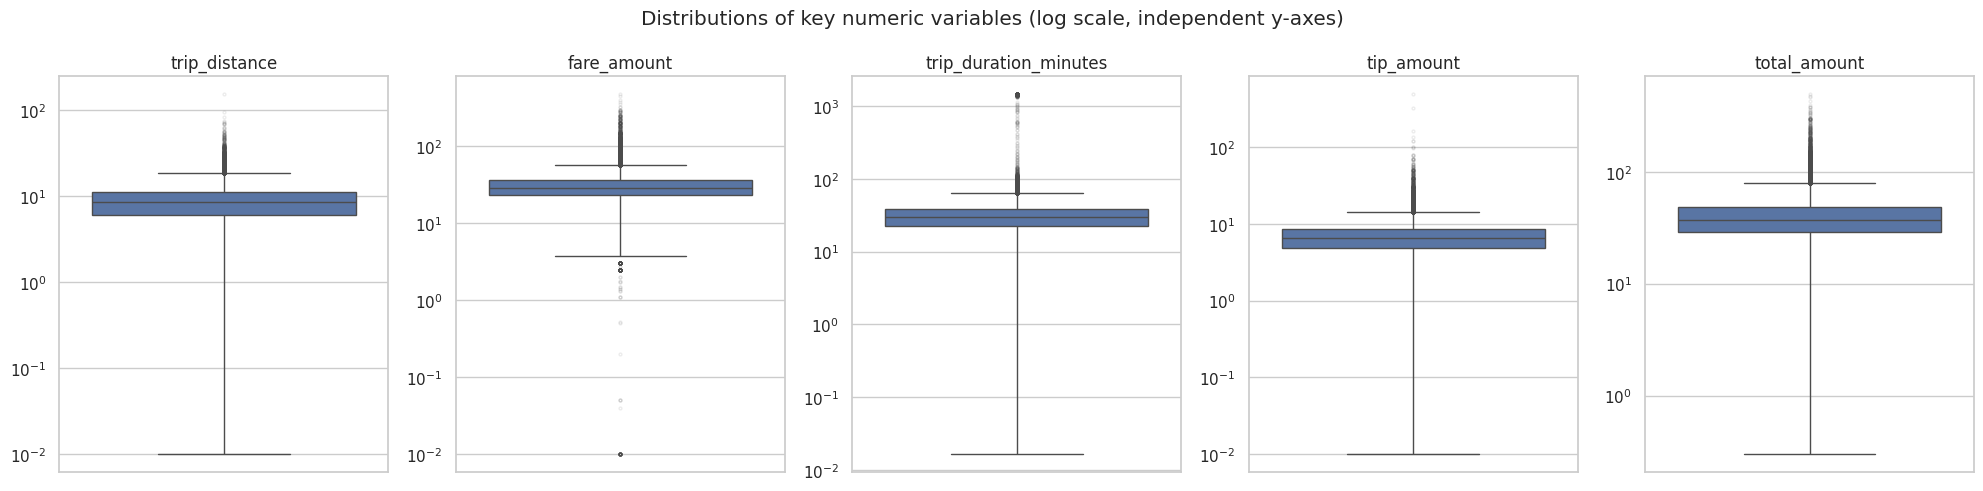

In [74]:
box_vars = [
    ("trip_distance", trips_temp["trip_distance"] > 0),
    ("fare_amount", trips_temp["fare_amount"] > 0),
    ("trip_duration_minutes", trips_temp["trip_duration_minutes"] > 0),
    ("tip_amount", trips_temp["tip_amount"] > 0),
    ("total_amount", trips_temp["total_amount"] > 0),
]

fig, axes = plt.subplots(1, len(box_vars), figsize=(4 * len(box_vars), 5))

for ax, (col, mask) in zip(axes, box_vars):
    sns.boxplot(
        y=trips_temp.loc[mask, col],
        ax=ax,
        fliersize=2,
        flierprops=dict(alpha=0.1),
    )
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_ylabel("")

fig.suptitle("Distributions of key numeric variables (log scale, independent y-axes)")
plt.tight_layout()
plt.show()

The boxplots above show that all five variables share the
same right-skewed pattern already seen in the histograms: the box (IQR) sits in a narrow,
well-defined range, while a long tail of outliers extends several orders of magnitude above
it — consistent with occasional very long/expensive trips.

More notably, `trip_distance`, `trip_duration_minutes`, `tip_amount` and `total_amount` also
show a dense concentration of points near the lower whisker, close to zero. This is different
from `fare_amount`, where low-value outliers are sparser and more individually visible. This
suggests a non-trivial number of trips with very small (but non-zero) distance, duration, tip
or total amount.

## 5.5 Outliers

In [75]:
import numpy as np

def iqr_bounds_log(series):
    positive = series[series > 0]
    log_series = np.log10(positive)
    q1 = log_series.quantile(0.25)
    q3 = log_series.quantile(0.75)
    iqr = q3 - q1
    lower_log = q1 - 1.5 * iqr
    upper_log = q3 + 1.5 * iqr
    return 10**lower_log, 10**upper_log

outlier_summary = []

for col in ["trip_distance", "fare_amount", "trip_duration_minutes", "tip_amount", "total_amount"]:
    lower, upper = iqr_bounds_log(trips_temp[col])
    n_outliers = ((trips_temp[col] < lower) | (trips_temp[col] > upper)).sum()
    pct = n_outliers / len(trips_temp) * 100
    outlier_summary.append({
        "column": col,
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers": n_outliers,
        "pct_outliers": round(pct, 2)
    })

pd.DataFrame(outlier_summary)

,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,trip_distance,2.46,27.80,9564,9.56
1,fare_amount,11.90,73.10,8421,8.42
2,trip_duration_minutes,10.22,86.28,8114,8.11
3,tip_amount,2.07,20.18,25780,25.78
4,total_amount,13.32,107.07,7380,7.38


I'm using the IQR on the log-transformed data because the columns are strongly right-skewed. If I ran the IQR on the raw values instead, it would probably flag a lot more outliers than are actually real.

**Business-rule outliers** (already surfaced in 5.2/5.3 — logically invalid values):
- `trip_distance <= 0` → 2,765 rows (~2.77%)
- `pickup_location_id == dropoff_location_id` → 6,165 rows
- `trip_duration_minutes < 0` → 5 rows (see 5.3 — all linked to the Nov 4, 2018 DST transition)
- `trip_duration_minutes == 0` → 208 rows

**Statistical outliers** (IQR applied on log-transformed values, since these
columns are strongly right-skewed — see 5.4):

| Column | Lower bound | Upper bound | Outliers | % of sample |
|---|---|---|---|---|
| `trip_distance` | 2.46 | 27.80 | 9,564 | 9.56% |
| `fare_amount` | 11.90 | 73.10 | 8,421 | 8.42% |
| `trip_duration_minutes` | 10.22 | 86.28 | 8,114 | 8.11% |
| `tip_amount` | 2.07 | 20.18 | 25,780 | 25.78% |
| `total_amount` | 13.32 | 107.07 | 7,380 | 7.38% |

Most columns show 7-10% statistical outliers, split between unusually short
and unusually long/high trips (expected given the right-skew already seen
in 5.4.)

`tip_amount` stands out with 25.78%, much higher than the rest. This is
likely an artifact of how tips are recorded rather than a genuine spike in
extreme values: cash trips typically have `tip_amount = 0` (not captured),
so the bulk of the distribution sits very close to zero, pushing the IQR
lower bound (2.07) inside what is actually normal, common behavior rather
than a true outlier region. This will be investigated further in 5.6
(e.g. checking `tip_amount` against `payment_type`) before deciding on any
rule for this column.

## 5.6 Relationships between variables

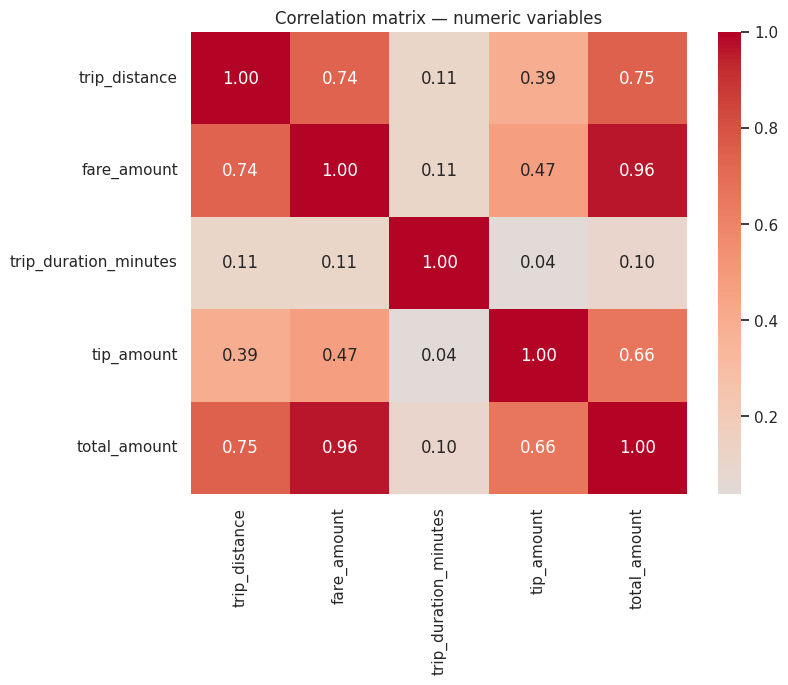

In [76]:
corr_cols = ["trip_distance", "fare_amount", "trip_duration_minutes", "tip_amount", "total_amount"]
correlation_matrix = trips_temp[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric variables")
plt.show()

The correlation matrix shows two clear groups of behavior:

**Strong correlations (0.7+):**
- `fare_amount` × `total_amount` (0.96) (expected, since `total_amount` is
  derived from `fare_amount` plus extras)
- `trip_distance` × `total_amount` (0.75) and `trip_distance` × `fare_amount`
  (0.74) (expected, longer trips cost more)

**Weak correlation — `trip_duration_minutes`:** unlike the other variables,
trip duration barely correlates with anything (0.04-0.11 across the board,
including `trip_distance` at just 0.11). This is unexpected, because a longer trip
distance should generally take longer. This weak relationship is likely
explained by traffic/speed variation (a short distance in heavy traffic can
take as long as a longer distance on an open road), but it's worth
investigating further with a dedicated scatter plot.

**Moderate correlation — `tip_amount`:** correlates at 0.39-0.66 with the
other monetary columns — weaker than `fare_amount`/`total_amount` between
themselves, consistent with the 5.5 finding that tipping behavior isn't
purely proportional to fare (likely due to payment-type differences, to be
checked next).

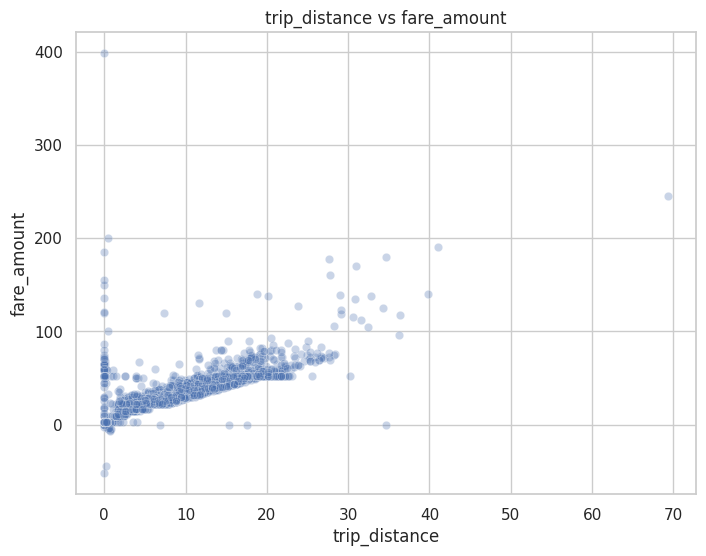

In [77]:
sample = trips_temp.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x="trip_distance", y="fare_amount", alpha=0.3)
plt.title("trip_distance vs fare_amount")
plt.xlabel("trip_distance")
plt.ylabel("fare_amount")
plt.show()

The scatter confirms the strong correlation seen in the matrix (0.74): most
points form a clear upward band, with fare increasing steadily as distance
increases. However, two anomalies stand out that weren't visible in the
correlation coefficient alone:

- A cluster of points at `trip_distance = 0` spanning a wide range of fares
  (from negative values up to ~$400) — this doesn't fit a simple "zero
  distance, zero fare" expectation, and may indicate flat-rate trips (e.g.
  airport fares) or GPS/meter malfunctions.
- A trip near `trip_distance ≈ 35` with `fare_amount = 0` — a long ride with
  no charge, which is inconsistent with the rest of the pattern and worth
  flagging as a candidate for the outlier/data quality rules in section 9.

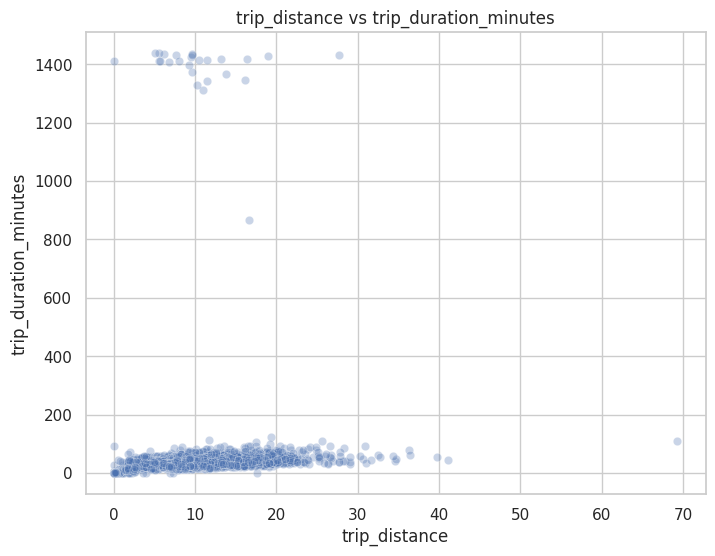

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x="trip_distance", y="trip_duration_minutes", alpha=0.3)
plt.title("trip_distance vs trip_duration_minutes")
plt.xlabel("trip_distance")
plt.ylabel("trip_duration_minutes")
plt.show()

This scatter explains the unexpectedly weak correlation (0.11) found in the
correlation matrix. Most points form a reasonable, dense cluster near the
origin (short distances, short durations). However, there is a distinct
horizontal band of points sitting near 1,400-1,440 minutes (roughly 24
hours) across a wide range of distances (5-30 miles) — a duration this long
for these distances is not plausible.

Since 1,440 minutes is exactly 24 hours, this suggests a data issue rather
than genuine long trips — most likely a `dropoff_datetime` recorded on the
wrong day. Let's check this directly.

In [79]:
long_duration = trips_temp[
    (trips_temp["trip_duration_minutes"] >= 1400) &
    (trips_temp["trip_duration_minutes"] <= 1450)
]

long_duration.shape

(300, 26)

In [80]:
day_diff = (
    long_duration["dropoff_datetime"].dt.normalize()
    - long_duration["pickup_datetime"].dt.normalize()
).dt.days

day_diff.value_counts()

1    298
0      2
Name: count, dtype: int64

In [81]:
long_duration[["pickup_datetime", "dropoff_datetime", "trip_duration_minutes"]].head(10)

,pickup_datetime,dropoff_datetime,trip_duration_minutes
410,2018-04-27 19:02:21,2018-04-28 18:38:41,1416.333333
1412,2018-11-05 14:47:50,2018-11-06 14:34:56,1427.100000
1674,2018-03-28 12:08:57,2018-03-29 11:30:48,1401.850000
2243,2018-11-29 11:08:53,2018-11-30 10:45:42,1416.816667
2302,2018-06-09 17:25:42,2018-06-10 16:47:31,1401.816667
2802,2018-07-13 00:50:55,2018-07-14 00:50:12,1439.283333
3604,2018-07-12 20:07:10,2018-07-13 19:30:43,1403.550000
3695,2018-11-22 21:27:57,2018-11-23 21:24:11,1436.233333
4241,2018-12-18 09:15:51,2018-12-19 08:48:10,1412.316667
4268,2018-03-24 18:54:28,2018-03-25 18:51:36,1437.133333


**Finding:** 300 rows in the sample fall in the 1,400-1,450 minute range. For 298 of them (99.3%), `dropoff_datetime` is exactly one calendar day after `pickup_datetime`, and the sample of rows above shows a similar time-of-day between pickup and dropoff — this confirms the date-rollover hypothesis: the date component of `dropoff_datetime` is off by one day, while the time-of-day is roughly correct. The remaining 2 rows share the same calendar day, which is a different, much smaller anomaly and will be reviewed individually rather than assumed to follow the same pattern.

Given the small share of affected rows (0.3% of the sample) and the risk of introducing new errors with an automatic date correction, these 300 rows will be removed during the pipeline's transformation stage rather than corrected — the same simplicity-first approach applied to the other small-impact anomalies in this project.

In [82]:
payment_map = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
}

trips_temp["payment_type_label"] = trips_temp["payment_type"].map(payment_map)

Payment type codes were mapped to their labels based on the dataset's official documentation.

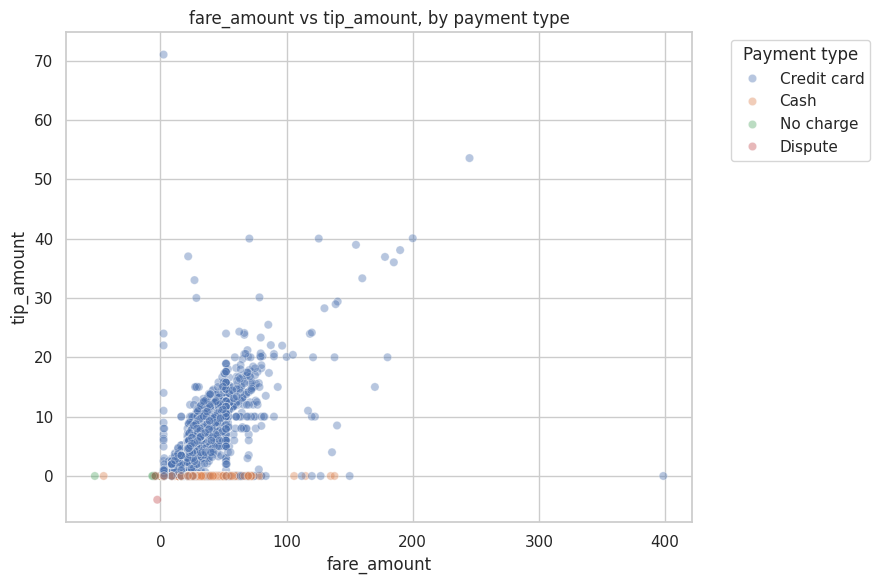

In [83]:
sample = trips_temp.sample(5000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample,
    x="fare_amount",
    y="tip_amount",
    hue="payment_type_label",
    alpha=0.4
)
plt.title("fare_amount vs tip_amount, by payment type")
plt.xlabel("fare_amount")
plt.ylabel("tip_amount")
plt.legend(title="Payment type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

This scatter confirms the hypothesis raised in 5.5: `tip_amount` outliers
are strongly tied to `payment_type`, not a data quality issue.

- **Credit card** trips show a clear, expected pattern: `tip_amount`
  increases with `fare_amount`, forming a visible upward trend with natural
  spread (people tip proportionally, but not identically).
- **Cash**, **No charge**, and **Dispute** trips sit almost entirely at
  `tip_amount = 0`, regardless of fare size. This is expected, since cash tips generally aren't captured in the
  system, and "no charge"/"dispute" trips wouldn't have a standard tip
  recorded either.

This explains why `tip_amount` had the highest statistical outlier rate in
5.5 (25.78%): with roughly half the trips reporting a `tip_amount` of
exactly 0 (cash and other non-card payments) and the rest following a
proportional tipping pattern (credit card), the IQR method, applied
without splitting by payment type, flags a large share of legitimate
card-tip values as outliers, simply because the distribution is a mix of
two very different behaviors rather than one.

**Implication for the pipeline:** the outlier/Data Quality rule for
`tip_amount` (section 9) should not apply uniformly. It's more meaningful
to only evaluate `tip_amount` outliers within `Credit card` trips, and
treat `tip_amount = 0` as expected (not anomalous) for Cash/No charge/
Dispute trips.

### 5.6 Summary

The correlation and scatter analysis confirmed expected relationships
(`fare_amount` ↔ `trip_distance` ↔ `total_amount`) while surfacing findings
not caught in earlier sections:

- `trip_distance = 0` trips span a wide range of fares (including negative
  values), and one ~35-mile trip has `fare_amount = 0` — both flagged as
  candidates for the Data Quality rules in section 9.
- A cluster of 300 trips (0.3% of the sample) with `trip_duration_minutes`
  near 1,440 (24 hours) — confirmed as a `dropoff_datetime` date rollover
  (298 of the 300 rows are exactly one day off), not genuine long trips.
  These rows will be removed in the pipeline.
- `tip_amount`'s high outlier rate (found in 5.5) is explained by
  `payment_type`: cash/no-charge/dispute trips report `tip_amount = 0`,
  while credit card trips follow a proportional tipping pattern. Outlier
  detection for `tip_amount` should be scoped to credit card trips only.

These findings will feed directly into the Data Quality rules drafted in
section 9.

# 6. EDA - taxi_zone_geo

## 6.1 Structure

`taxi_zone_geo` was already inspected via `quick(zones)` in section 3: 263 rows, 4 columns (`zone_id`, `zone_name`, `borough`, `zone_geom`), and no null values in any column. `zone_id` is stored as `int64`; `zone_name`, `borough`, and `zone_geom` are all `object` (text) — expected, since `zone_geom` stores a WKT polygon string rather than a simple category.

In [84]:
zones["borough"].value_counts()

borough
Manhattan        69
Queens           69
Brooklyn         61
Bronx            43
Staten Island    20
EWR               1
Name: count, dtype: int64

In [85]:
zones["zone_id"].min(), zones["zone_id"].max()

(np.int64(1), np.int64(263))

## 6.2 Quality

In [86]:
zones.duplicated().sum()

np.int64(0)

In [87]:
zones["zone_name"].duplicated().sum()

np.int64(3)

In [97]:
zones.duplicated().sum()        # → 0   (nenhuma linha 100% idêntica a outra)
zones["zone_id"].duplicated().sum()   # → 3  (3 valores de zone_id repetidos)
zones["zone_name"].duplicated().sum() # → 3  (3 valores de zone_name repetidos)

np.int64(3)

In [98]:
dup_zone_ids = zones[zones["zone_id"].duplicated(keep=False)].sort_values("zone_id")
dup_zone_ids

,zone_id,zone_name,borough,zone_geom
57,56,Corona,Queens,"POLYGON((-73.8537828699998 40.747802991, -73.8..."
58,56,Corona,Queens,"POLYGON((-73.8508643969999 40.7499956419999, -..."
192,103,Governor's Island/Ellis Island/Liberty Island,Manhattan,"POLYGON((-74.0446061649146 40.6905734844753, -..."
193,103,Governor's Island/Ellis Island/Liberty Island,Manhattan,"POLYGON((-74.0402880871895 40.7006436132336, -..."
194,103,Governor's Island/Ellis Island/Liberty Island,Manhattan,"POLYGON((-74.0168218764196 40.6933455811375, -..."


## 6.3 Zone integrity

In [89]:
zones["zone_id"].is_unique

False

In [90]:
zones["zone_id"].nunique(), zones.shape[0]

(260, 263)

# 7. Relationship: Trips × Zones

## 7.1 Pickup zones

In [91]:
pickup_counts = trips_temp["pickup_location_id"].value_counts()

pickup_counts.head(10)

pickup_location_id
138    21320
132     9344
230     3272
161     2878
162     2633
186     2304
48      2228
163     2112
170     2021
236     1980
Name: count, dtype: int64

In [92]:
pickup_counts.tail(10)

pickup_location_id
206    1
9      1
184    1
122    1
96     1
147    1
5      1
180    1
240    1
58     1
Name: count, dtype: int64

## 7.2 Dropoff zones

In [93]:
dropoff_counts = trips_temp["dropoff_location_id"].value_counts()

dropoff_counts.head(10)

dropoff_location_id
138    9360
230    2618
161    2251
132    2220
162    2072
231    1720
13     1669
236    1664
265    1592
1      1577
Name: count, dtype: int64

In [94]:
dropoff_counts.tail(10)

dropoff_location_id
109    5
184    4
187    4
176    4
44     4
204    4
253    4
5      3
30     2
59     1
Name: count, dtype: int64

## 7.3 Unmatched records

In [95]:
valid_zone_ids = set(zones["zone_id"])

unmatched_pickup = trips_temp[~trips_temp["pickup_location_id"].isin(valid_zone_ids)]
unmatched_dropoff = trips_temp[~trips_temp["dropoff_location_id"].isin(valid_zone_ids)]

unmatched_pickup.shape, unmatched_dropoff.shape

((2219, 27), (3073, 27))

Pickup is far more concentrated than dropoff: zone `138` accounts for ~21.3% of pickups vs.
~9.4% of dropoffs, suggesting it works more as an origin hub than a destination. Unmatched
`zone_id`s are non-trivial (~2.2% pickup, ~3.1% dropoff) and represent a real data quality
issue requiring a pipeline decision (drop/flag/investigate).

# 8. Conclusions

This EDA confirms `taxi_trip_data` is usable as the primary source for the pipeline, but not without a defined set of cleaning and monitoring rules.

**Data quality.** The sample contains a small number of clearly invalid records (duplicates, non-positive `trip_distance`, non-positive `total_amount`, negative trip durations) that together affect a low single-digit percentage of rows — not enough to change the dataset's overall shape, but enough to require explicit handling in the pipeline rather than being ignored.

**Explained anomalies.** Two findings stood out and were investigated to a root cause rather than treated as unexplained noise: the negative-duration trips all trace back to the November 2018 DST transition, and the ~24-hour duration cluster traces back to a `dropoff_datetime` date rollover affecting 300 rows. Both are documented in section 9 with a specific handling rule instead of a blanket 'remove all outliers' approach.

**Temporal patterns.** Trip volume follows expected daily and weekly commuting patterns (weekday and evening peaks), with one unexplained exception: March shows roughly double the volume of any other month, a finding that survived every data quality check applied and is treated as a genuine characteristic of the dataset, flagged for pipeline monitoring rather than correction.

**Relationships between variables.** Fare-related columns behave as expected (distance and fare are strongly correlated); `tip_amount` requires payment-type-aware handling rather than a single outlier rule.

**Zones (pending).** Sections 6 and 7 will determine whether `taxi_zone_geo` is a clean, reliable lookup table and whether every trip's pickup/dropoff location resolves to a known zone. This conclusion will be updated once those sections are run.

# 9. Pipeline requirements

- Convert `pickup_datetime` and `dropoff_datetime` from object to datetime
- Create an auxiliary lookup table for `payment_type` codes
- Treat `rate_code` and `store_and_fwd_flag` as categorical
- Remove exact duplicate rows (53 duplicates / 106 rows in the 100k sample)
- Filter out rows with `trip_distance <= 0` (2,765 rows, ~2.77% of the 100k sample)
- Remove rows with negative `trip_duration_minutes` — all 5 cases in the
  sample are linked to the Nov 4, 2018 DST transition, not random errors
- Remove rows with `trip_duration_minutes` near 1,440 (~24h) — 300 rows
  in the sample (0.3%), of which 298 have a `dropoff_datetime` exactly
  one calendar day after `pickup_datetime` with a similar time-of-day,
  confirming a date rollover rather than a genuine long trip; the
  remaining 2 rows will be reviewed individually
- Decide how to handle rows with `trip_duration_minutes == 0` (208 rows) — pending investigation
- Decide how to handle `pickup_location_id == dropoff_location_id` rows (6,165 rows) — pending investigation
- Treat `vendor_id == 4` (507 rows) and `rate_code == 99` (13 rows) as an
  'unknown/unmapped' category rather than removing them
- Apply statistical outlier bounds (log-IQR, see 5.5) as Data Quality
  monitoring rules, not automatic removal — treat detected outliers as
  flags for review
- Scope `tip_amount` outlier detection to `payment_type == Credit card`
  only (cash/no-charge/dispute trips legitimately report `tip_amount = 0`)
- Add a monitoring rule for monthly trip volume (flag deviations from the
  historical average) — motivated by the unexplained March volume spike
  found in 5.3
- Deduplicate `taxi_zone_geo` on `zone_id` before using it as the primary
  key for `dim_zone` — 3 `zone_id` values are currently duplicated, and
  since no full-row duplicates exist in the table (`zones.duplicated().sum() == 0`),
  these are conflicting rows (same `zone_id`, different `zone_name`/`borough`),
  not harmless repeats. Resolve by inspecting `zones[zones["zone_id"].duplicated(keep=False)]`
  and deciding which row to keep (or how to correct the name) before loading `dim_zone`.
  Validate with `zone_id.is_unique == True` after the fix.
- Define a rule for trips whose `pickup_location_id` / `dropoff_location_id`
  has no match in `taxi_zone_geo.zone_id` — 2,219 pickup rows (~2.2%) and
  3,073 dropoff rows (~3.1%) in the sample are affected. These appear to be
  legitimate NYC TLC placeholder codes (e.g. 264/265) that simply fall
  outside the zone lookup's range (1–263), rather than random errors —
  likely fix is adding an explicit "Unknown zone" row to `dim_zone` rather
  than dropping or nulling these trips.